# Cosine Similarity vs Server Reference: Outlier Detection

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from sklearn.metrics import confusion_matrix
from matplotlib.lines import Line2D

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

RUN_NAME = "fedavg_mlp_adult-income-census_ep5_lr0.001_bs8_iid_attack_mpaf_lambda0.3"
RUN_NAME = "FEDAVG_mlp_adult-income-census_ep3_lr0.001_bs8_iid_attack_mpaf_lambda10"

BASE_PATH = Path("../experiments/shap_outputs") / RUN_NAME
Z_THRESH = 2.0  # flag if score < mu - Z_THRESH * sigma

print(f"Run      : {RUN_NAME}")
print(f"Path     : {BASE_PATH}")
print(f"Z-thresh : {Z_THRESH}")

Run      : FEDAVG_mlp_adult-income-census_ep3_lr0.001_bs8_iid_attack_mpaf_lambda10
Path     : ../experiments/shap_outputs/FEDAVG_mlp_adult-income-census_ep3_lr0.001_bs8_iid_attack_mpaf_lambda10
Z-thresh : 2.0


In [2]:
# ── Loaders & similarity function ─────────────────────────────────────────────


def load_json(path):
    try:
        with open(path) as f:
            return json.load(f)
    except Exception:
        return {}


def load_npz_vector(path):
    """Load first array from .npz and reduce to a 1-D per-feature vector."""
    try:
        z = np.load(path, allow_pickle=True)
        arr = np.asarray(z[list(z.keys())[0]])
        if arr.ndim == 0:
            return np.array([float(arr)])
        if arr.ndim == 1:
            return arr
        return np.mean(arr, axis=0)  # (n_samples, n_features) -> (n_features,)
    except Exception:
        return None


def cosine_sim(a, b):
    """
    Cosine similarity between two 1-D vectors.
    Returns a value in [-1, 1]; higher = more similar direction.
    Returns 0.0 if either vector is zero.
    """
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a < 1e-10 or norm_b < 1e-10:
        return 0.0
    return float(np.dot(a, b) / (norm_a * norm_b))


print("Loaders defined.")

Loaders defined.


In [3]:
# ── Load server reference SHAP vector ─────────────────────────────────────────
# This is the fixed reference computed once before round 1 on the server's
# held-out explanation set using the initialised global model.

server_ref_path = BASE_PATH / "server-model" / "reference_shap.npz"
server_shap_ref = load_npz_vector(server_ref_path)

if server_shap_ref is not None:
    print(f"Server reference SHAP loaded — shape : {server_shap_ref.shape}")
    print(
        f"  min={server_shap_ref.min():.4f}  max={server_shap_ref.max():.4f}  "
        f"mean={server_shap_ref.mean():.4f}  norm={np.linalg.norm(server_shap_ref):.4f}"
    )
else:
    raise FileNotFoundError(
        f"Server reference SHAP not found at: {server_ref_path}\n"
        "Check that BASE_PATH / 'server-model' / 'reference_shap.npz' exists."
    )

Server reference SHAP loaded — shape : (30,)
  min=-0.1786  max=0.0731  mean=-0.0096  norm=0.2323


In [4]:
# ── Load all client SHAP vectors across rounds ─────────────────────────────────
client_data = defaultdict(dict)
round_dirs = sorted(
    [d for d in BASE_PATH.iterdir() if d.is_dir() and d.name.startswith("round_")]
)

print(f"Found {len(round_dirs)} rounds.")

for rdir in round_dirs:
    rnum = int(rdir.name.split("_")[1])
    for cdir in sorted([d for d in rdir.iterdir() if d.is_dir()]):
        cid = cdir.name
        meta = load_json(cdir / "metadata.json")
        sv = load_npz_vector(cdir / "shap_values.npz")
        if sv is None:
            continue
        if cid not in client_data:
            client_data[cid] = {
                "is_malicious": bool(
                    meta.get("malicious", meta.get("is_malicious", False))
                ),
                "rounds": {},
            }
        client_data[cid]["rounds"][rnum] = sv

n_mal = sum(1 for c in client_data.values() if c["is_malicious"])
n_ben = sum(1 for c in client_data.values() if not c["is_malicious"])
print(f"Clients loaded : {len(client_data)}  |  malicious: {n_mal}  |  benign: {n_ben}")

Found 20 rounds.
Clients loaded : 30  |  malicious: 15  |  benign: 15


## Per-Round Cosine Similarity Scores

In [5]:
all_rounds = sorted({r for c in client_data.values() for r in c["rounds"]})
records = []

for rnum in all_rounds:
    for cid, cinfo in client_data.items():
        if rnum not in cinfo["rounds"]:
            continue
        sv = cinfo["rounds"][rnum]
        records.append(
            {
                "round": rnum,
                "client": cid,
                "is_malicious": cinfo["is_malicious"],
                "cosine_sim": cosine_sim(sv, server_shap_ref),
            }
        )

df = pd.DataFrame(records)
print(
    f"Score table: {len(df)} rows  |  rounds: {df['round'].nunique()}  |  clients: {df['client'].nunique()}"
)
print()
print(df.groupby("is_malicious")["cosine_sim"].describe().T)

Score table: 600 rows  |  rounds: 20  |  clients: 30

is_malicious       False       True 
count         300.000000  300.000000
mean            0.583314    0.516491
std             0.132124    0.227318
min            -0.834022   -0.603144
25%             0.536013    0.520914
50%             0.572104    0.558233
75%             0.652468    0.634115
max             0.806508    0.774993


In [6]:
# # ── Per-round z-score flagging ─────────────────────────────────────────────────
# round_stats = (
#     df.groupby('round')['cosine_sim']
#     .agg(['mean', 'std'])
#     .rename(columns={'mean': 'cs_mu', 'std': 'cs_sigma'})
#     .reset_index()
# )

# df = df.merge(round_stats, on='round')
# # Low cosine similarity = suspicious (client points in a different direction from server reference)
# df['flagged'] = df['cosine_sim'] < (df['cs_mu'] - Z_THRESH * df['cs_sigma'])

# print("Per-round flag counts:")
# print(df.groupby('round')['flagged'].sum().rename('n_flagged').to_frame())

In [7]:
# ── Per-round IQR flagging ──────────────────────────────────────────────────────
round_stats = (
    df.groupby("round")["cosine_sim"]
    .agg(
        cs_q1=lambda x: x.quantile(0.25),
        cs_q3=lambda x: x.quantile(0.75),
    )
    .reset_index()
)

IQR_THRESH = 1.5

round_stats["cs_iqr"] = round_stats["cs_q3"] - round_stats["cs_q1"]
round_stats["cs_lower"] = round_stats["cs_q1"] - IQR_THRESH * round_stats["cs_iqr"]
round_stats["cs_upper"] = round_stats["cs_q3"] + IQR_THRESH * round_stats["cs_iqr"]

df = df.merge(round_stats, on="round")
# Flag clients that are outliers in either direction
df["flagged"] = (df["cosine_sim"] < df["cs_lower"]) | (
    df["cosine_sim"] > df["cs_upper"]
)
print("Per-round flag counts:")
print(df.groupby("round")["flagged"].sum().rename("n_flagged").to_frame())

Per-round flag counts:
       n_flagged
round           
1              0
2              0
3              1
4              0
5              0
6              0
7              0
8              0
9              0
10             0
11             0
12             0
13             0
14             0
15             0
16             1
17             0
18             0
19             0
20             0


## Score Visualisation

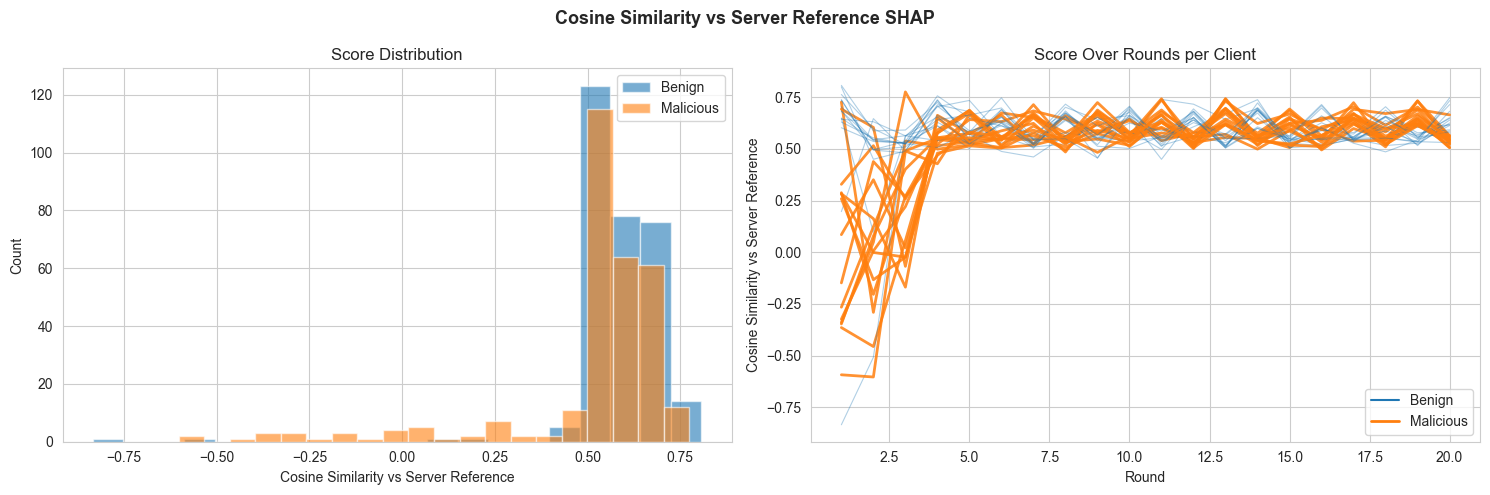

In [8]:
# ── Distribution + evolution over rounds ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: histogram by ground-truth label
ax = axes[0]
for label, grp in df.groupby("is_malicious"):
    color = "tab:orange" if label else "tab:blue"
    name = "Malicious" if label else "Benign"
    ax.hist(
        grp["cosine_sim"],
        bins=20,
        alpha=0.6,
        color=color,
        label=name,
        edgecolor="white",
    )
ax.set_xlabel("Cosine Similarity vs Server Reference")
ax.set_ylabel("Count")
ax.set_title("Score Distribution")
ax.legend()

# Right: score trajectory per client across rounds
ax = axes[1]
for cid, grp in df.groupby("client"):
    is_mal = grp["is_malicious"].iloc[0]
    color = "tab:orange" if is_mal else "tab:blue"
    alpha = 0.85 if is_mal else 0.35
    lw = 2.0 if is_mal else 0.8
    ax.plot(grp["round"], grp["cosine_sim"], color=color, alpha=alpha, linewidth=lw)

legend_elements = [
    Line2D([0], [0], color="tab:blue", linewidth=1.5, label="Benign"),
    Line2D([0], [0], color="tab:orange", linewidth=2.0, label="Malicious"),
]
ax.legend(handles=legend_elements)
ax.set_xlabel("Round")
ax.set_ylabel("Cosine Similarity vs Server Reference")
ax.set_title("Score Over Rounds per Client")

plt.suptitle(
    "Cosine Similarity vs Server Reference SHAP", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_116408/2081976834.py:35: UserWarning: Glyph 9670 (\N{BLACK DIAMOND}) missing from font(s) Arial.
  plt.tight_layout()
/home/b-fatma/miniconda3/envs/flwr/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9670 (\N{BLACK DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


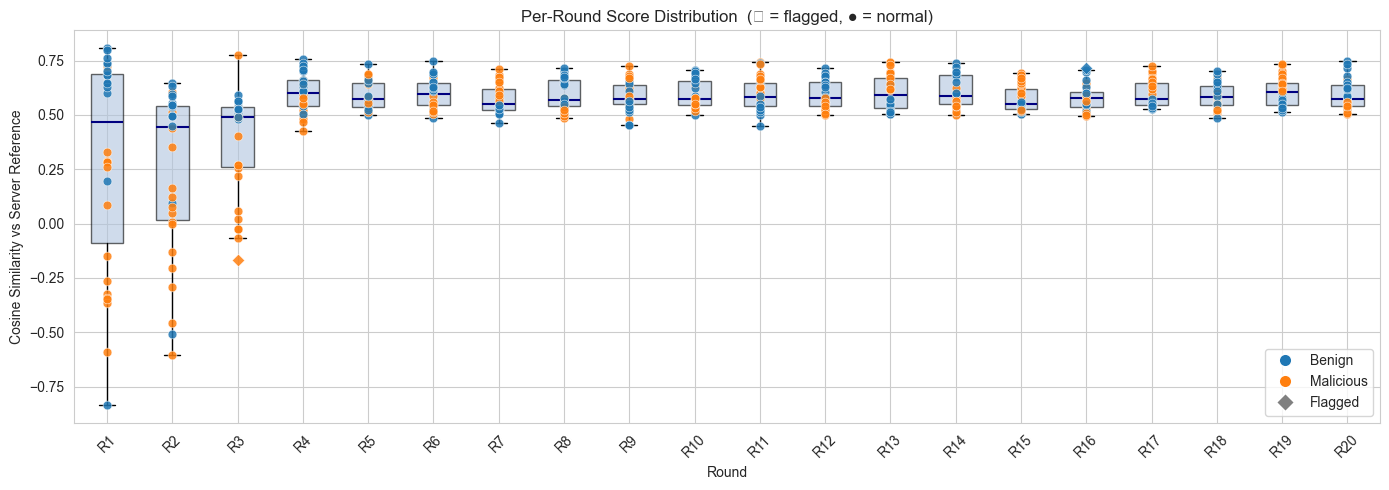

In [9]:
# ── Per-round box plot: score spread with flagged points highlighted ───────────
fig, ax = plt.subplots(figsize=(14, 5))

round_order = sorted(df["round"].unique())
positions = list(range(len(round_order)))
round_groups = [df[df["round"] == r]["cosine_sim"].values for r in round_order]

bp = ax.boxplot(
    round_groups,
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor="lightsteelblue", alpha=0.6),
    medianprops=dict(color="navy", linewidth=1.5),
)

# Overlay individual points, coloured by ground truth
for pos, rnum in zip(positions, round_order):
    rdf = df[df["round"] == rnum]
    for _, row in rdf.iterrows():
        color = "tab:orange" if row["is_malicious"] else "tab:blue"
        marker = "D" if row["flagged"] else "o"
        zorder = 5 if row["flagged"] else 3
        ax.scatter(
            pos,
            row["cosine_sim"],
            color=color,
            s=40,
            marker=marker,
            zorder=zorder,
            alpha=0.85,
            edgecolors="white",
            linewidths=0.4,
        )

ax.set_xticks(positions)
ax.set_xticklabels([f"R{r}" for r in round_order], rotation=45)
ax.set_xlabel("Round")
ax.set_ylabel("Cosine Similarity vs Server Reference")
ax.set_title("Per-Round Score Distribution  (◆ = flagged, ● = normal)")

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="tab:blue",
        markersize=9,
        label="Benign",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="tab:orange",
        markersize=9,
        label="Malicious",
    ),
    Line2D(
        [0],
        [0],
        marker="D",
        color="w",
        markerfacecolor="grey",
        markersize=9,
        label="Flagged",
    ),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

In [10]:
# Metrics
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = df["is_malicious"].astype(int)
y_pred = df["flagged"].astype(int)

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print("=" * 40)
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print("-" * 40)
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print("=" * 40)

  TP=1  FP=1  FN=299  TN=299
----------------------------------------
  Precision : 0.5000
  Recall    : 0.0033
  F1 Score  : 0.0066
